In [10]:
import os
import sys

import pickle
import torch
import torch.multiprocessing as mp
from torch.utils.data import DataLoader

# Add the repo root (e.g.,/fairmast-data-preprocessing) to sys.path
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in globals()
                                         else os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print(f"REPO_ROOT: {REPO_ROOT}")

from scripts.MAST_tools.MAST_dataset import MastDataset
from scripts.main_pipeline.utils.utils import read_data_split_csv, flatten_then_collate
from scripts.main_pipeline.preprocessing.sampled_shot_list import yamane_sampled_shot_list
from scripts.main_pipeline.preprocessing.standardscaling_preprocessing import get_mean_shot, get_std_shot
from scripts.main_pipeline.utils.utils import ComposeTransforms
from scripts.main_pipeline.transforms.signal_level_transformers.fill_with_zeros_imputer_transform import (
    FillWithZerosImputerTransform
)
from scripts.main_pipeline.transforms.signal_level_transformers.forward_fill_imputer_transform import (
    ForwardFillImputerTransform
)
from scripts.main_pipeline.transforms.signal_level_transformers.sample_wise_normalize_transform import (
    SamplewiseNormalizeTransform
)
from scripts.main_pipeline.transforms.signal_level_transformers.pretrained_stdscale_normalize_transform import(
    StdScalingTransform
)
from scripts.main_pipeline.transforms.signal_level_transformers.sampling_reference_time_transform import (
    SamplingToReferenceTimeTransform
)
from scripts.main_pipeline.transforms.shot_level_transformers.truncation_transform import (
    TruncationTransform
)
from scripts.main_pipeline.transforms.shot_level_transformers.window_segmenter_transform import (
    WindowSegmenterTransform
)
from scripts.main_pipeline.transforms.shot_level_transformers.drop_sample_with_nans import (
    DropSampleWithNans
)
from scripts.main_pipeline.transforms.signal_level_transformers.fill_profile_with_zeros_imputer_transform import (
    FillProfileWithZerosTransform
)

from scripts.main_pipeline.transforms.shot_level_transformers.cnn_transform import CNNTransform
from scripts.main_pipeline.models.cnn_model import MultiBranchCNNModel
from multiprocessing import cpu_count

print(f"\nNumber of Cores: {cpu_count()}\n")

# ----------------------------------------------------------------------------------------------------------------------
# Determine device to train on

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

REPO_ROOT: /home/ir-rous1

Number of Cores: 128



In [11]:
LOCAL_FLAG = True
mp.set_start_method("spawn", force=True)

# ..................................................................................................................
# For common pipeline

SUBSET_OF_SHOTS = None  # <- This can be None for the entire dataset, or a small integer.
OUTPUT_SUB_FOLDER = 'cnn_output_july_12/'  # <- Sub-folder within /output/
BATCH_SIZE = 500  # 500
NUM_WORKERS = 64  # 64
MAX_EPOCHS = 500

REF_FREQ = 0.005

In [12]:
# ----------------------------------------------------------------------------------------------------------------------
def get_train_test_val_shots(max_index=None):
    train_sh, test_sh, val_sh = read_data_split_csv()

    if max_index:
        train_sh = train_sh[0:max_index]
        val_sh = val_sh[0:max_index]
        test_sh = test_sh[0:max_index]

    return train_sh, test_sh, val_sh

In [13]:
# ----------------------------------------------------------------------------------------------------------------------
# def fit_mean_and_std_for_signal_transform(output_sub_dir, verbose=False):

#     if verbose:
#         print('\n\n----------TRANSFORM FITTING----------\n')

#     preprocessing_train_dataset = MastDataset(
#         local=LOCAL_FLAG,
#         shots_list=yamane_sampled_shot_list(train_shots, error=0.05),
#         source_signal_list=source_signal_list,
#         signal_level_transform_map=None,
#         shot_level_transform=None
#     )

#     if verbose:
#         print(f"len(preprocessing_train_dataset): {len(preprocessing_train_dataset)}")

#     dict_mean_ = get_mean_shot(preprocessing_train_dataset)
#     dict_std_ = get_std_shot(preprocessing_train_dataset)

#     # Save dict_mean and dict_std used!

#     output_dir = os.path.join("output", output_sub_dir)
#     os.makedirs(output_dir, exist_ok=True)
#     if verbose:
#         print(f"Output folder to save fitted mean and std dicts: {output_dir}")

#     with open(output_dir + 'dict_mean_shot.pkl', 'wb') as f:
#         pickle.dump(dict_mean_, f)
#     with open(output_dir + 'dict_std_shot.pkl', 'wb') as f:
#         pickle.dump(dict_std_, f)

#     return dict_mean_, dict_std_


# ----------------------------------------------------------------------------------------------------------------------
def initialize_datasets(
        sources_and_signals,
        shots,
        sig_tran_map,
        shot_tran,
        local_flag=False,
        verbose=False

):

    datasets_ = {"train": None, "val": None, "test": None}

    # ..................................................................................................................
    # Train

    if shots["train"]:
        datasets_["train"] = MastDataset(
            local=local_flag,
            shots_list=shots["train"],
            source_signal_list=sources_and_signals,
            signal_level_transform_map=sig_tran_map,
            shot_level_transform=shot_tran
        )
        if verbose:
            print(f"len(mast_train_dataset): {len(datasets_['train'])}")

    # ..................................................................................................................
    # Val

    if shots["val"]:
        datasets_["val"] = MastDataset(
            local=local_flag,
            shots_list=shots["val"],
            source_signal_list=sources_and_signals,
            signal_level_transform_map=sig_tran_map,
            shot_level_transform=shot_tran
        )
        if verbose:
            print(f"len(val_dataset): {len(datasets_['val'])}")

    # ..................................................................................................................
    # Test

    if shots["test"]:
        datasets_["test"] = MastDataset(
            local=local_flag,
            shots_list=shots["test"],
            source_signal_list=sources_and_signals,
            signal_level_transform_map=sig_tran_map,
            shot_level_transform=shot_tran
        )
        if verbose:
            print(f"len(test_dataset): {len(datasets_['test'])}")

    # ..................................................................................................................
    # Return

    return datasets_


# ----------------------------------------------------------------------------------------------------------------------
def initialize_dataloaders(
        datasets,
        collate_function,
        batch_size,
        num_workers,
        shuffle=True,
        drop_last=False,
        verbose=False
):

    dataloaders_ = {"train": None, "val": None, "test": None}

    if verbose:
        print('\n\n----------DATASET & DATALOADER INITIALIZATION----------\n')

    # ..................................................................................................................
    # Train

    if datasets["train"]:
        dataloaders_["train"] = DataLoader(
            dataset=datasets["train"],
            batch_size=batch_size,
            # batch_size=len(datasets['train']),
            num_workers=num_workers,
            shuffle=shuffle,
            drop_last=drop_last,
            collate_fn=collate_function
        )

    # ..................................................................................................................
    # Val

    if datasets["val"]:
        dataloaders_["val"] = DataLoader(
            dataset=datasets["val"],
            batch_size=batch_size,
            # batch_size=len(datasets["val"]),
            num_workers=num_workers,
            shuffle=shuffle,
            drop_last=drop_last,
            collate_fn=collate_function
        )

    # ..................................................................................................................
    # Test

    if datasets["test"]:
        dataloaders_["test"] = DataLoader(
            dataset=datasets["test"],
            batch_size=batch_size,
            # batch_size=len(datasets["test"]),
            num_workers=num_workers,
            shuffle=shuffle,
            drop_last=drop_last,
            collate_fn=collate_function
        )

    # ..................................................................................................................
    # Return

    return dataloaders_


# ----------------------------------------------------------------------------------------------------------------------
def create_cnn_architecture(
        train_dataloader_,
        verbose=False
):

    if verbose:
        print("\n\n----------MODEL INITIALIZATION----------\n")

    input_shapes = [arr.shape for arr in train_dataloader_.dataset[0][0][0]]
    if verbose:
        print(f"input_shapes: {input_shapes}")

    output_shape = [arr.shape for arr in train_dataloader_.dataset[0][0][1]]
    if verbose:
        print(f"output_shape: {output_shape}")

    return MultiBranchCNNModel(input_shapes, output_shape).to(device)


# ----------------------------------------------------------------------------------------------------------------------
def loop_for_cnn_training(
        base_cnn_model,
        lr,
        best_val_loss,
        loss_criterion,
        patience,
        output_sub_dir,
        verbose=False

):

    if verbose:
        print('\n\n----------CNN TRAINING----------\n')

    output_dir = os.path.join("output", output_sub_dir)
    os.makedirs(output_dir, exist_ok=True)
    if verbose:
        print(f"Output folder to save trained model: {output_dir}")

    optimizer = torch.optim.Adam(base_cnn_model.parameters(), lr=lr)

    best_model_state_ = None
    early_stop_ = False
    epochs_no_improve = 0
    for epoch in range(MAX_EPOCHS):
        base_cnn_model.train()
        running_loss = 0.0
        num_batches = 0

        if verbose:
            print(f'\nEpoch {epoch+1}\n')

        for batch_idx, (x_train, y_train) in enumerate(train_dataloader):

            x_train = [arr.to(torch.float32).to(device) for arr in x_train]
            # print([arr.shape for arr in x_train])
            # print(y_train.min().item(), y_train.max().item())

            y_train = y_train[0].to(torch.float32).to(device)
            if verbose:
                # print(y_train.shape)
                print(f'Batch {batch_idx} size is {len(y_train)}')

            outputs_ = base_cnn_model(*x_train).squeeze()
            loss_ = loss_criterion(outputs_, y_train)
            if verbose:
                # print(f"outputs' shape: {outputs_.shape}")
                print(f'Batch loss: {loss_}')

            optimizer.zero_grad()
            loss_.backward()
            optimizer.step()

            running_loss += loss_.item()
            num_batches += len(y_train)
            if verbose:
                print(f'Actual num_batches is {num_batches}')

        avg_loss = running_loss / num_batches
        # print(f"Epoch [{epoch+1}/{MAX_EPOCHS}], Average Loss: {avg_loss:.4f}")

        # Validation phase & Early stopping check

        base_cnn_model.eval()
        val_running_loss = 0.0
        val_batches = 0

        with torch.no_grad():
            for x_val, y_val in val_dataloader:
                x_val = [arr.to(torch.float32).to(device) for arr in x_val]
                y_val = y_val[0].to(torch.float32).to(device)

                val_outputs = base_cnn_model(*x_val).squeeze()
                val_loss = loss_criterion(val_outputs, y_val)

                val_running_loss += val_loss.item()
                val_batches += len(y_val)

        avg_val_loss = val_running_loss / val_batches
        if verbose:
            print(f"Epoch [{epoch+1}/{MAX_EPOCHS}], Average Loss: {avg_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state_ = base_cnn_model.state_dict()

            # Save best model state
            torch.save(best_model_state_, output_dir + "best_model.pt")

        else:
            epochs_no_improve += 1
            if verbose:
                print(f"No improvement for {epochs_no_improve} epochs.")
            if epochs_no_improve >= patience:
                early_stop_ = True
                if verbose:
                    print("Early stopping triggered.")
                break

    return best_model_state_, early_stop_

In [14]:
LOCAL_FLAG = True
mp.set_start_method("spawn", force=True)

# ..................................................................................................................
# For common pipeline

SUBSET_OF_SHOTS = None  # <- This can be None for the entire dataset, or a small integer.
OUTPUT_SUB_FOLDER = 'cnn_output/'  # <- Sub-folder within /output/
BATCH_SIZE = 500  # 500
NUM_WORKERS = 64  # 64
MAX_EPOCHS = 500

REF_FREQ = 0.005

source_signal_list = [
    ('magnetics', 'flux_loop_flux'),
    ('magnetics', 'b_field_pol_probe_ccbv_field'),
    ('magnetics', 'b_field_pol_probe_obr_field'),
    ('magnetics', 'b_field_pol_probe_obv_field'),
    ('pf_active', 'solenoid_current'),
    ('pf_active', 'coil_voltage'),
    ('pf_active', 'coil_current'),
    ('pulse_schedule', 'i_plasma'),
    ('summary', 'power_nbi'),
    ('equilibrium', 'elongation'),
    ('equilibrium', 'elongation_axis'),
    ('equilibrium', 'triangularity_upper'),
    ('equilibrium', 'triangularity_lower'),
    ('equilibrium', 'minor_radius'),
    ('equilibrium', 'magnetic_axis_r'),
    ('equilibrium', 'magnetic_axis_z')
]

# ..................................................................................................................
# For CNN pipeline

PARAMETERS_WINDOWS_SEGMENTER = {
    'x_keys': [
        'magnetics-flux_loop_flux',
        'magnetics-b_field_pol_probe_ccbv_field',
        'magnetics-b_field_pol_probe_obr_field',
        'magnetics-b_field_pol_probe_obv_field',
        'pf_active-solenoid_current',
        'pf_active-coil_voltage',
        'pf_active-coil_current',
        'pulse_schedule-i_plasma',
        'summary-power_nbi',
    ],
    'y_keys': [
        'equilibrium-elongation',
        'equilibrium-elongation_axis',
        'equilibrium-triangularity_upper',
        'equilibrium-triangularity_lower',
        'equilibrium-minor_radius',
        'equilibrium-magnetic_axis_r',
        'equilibrium-magnetic_axis_z',
    ],
    'x_window_sec': 0,
    'y_window_sec': 0,
    'dt_sec': 0.025,
    'stride_sec': None,
    'stride_unitary': True,
    'min_samples_per_window': 1,
    'verbose': False,
}


In [15]:
# ..................................................................................................................
# For CNN training

LOSS_CRITERION = torch.nn.MSELoss()
LEARNING_RATE = 1e-4
BEST_VALUE_LOSS = float('inf')
PATIENCE = 5  # <- Maximum number of admissible epochs without improvement
RUN_EVALUATION = False

# ------------------------------------------------------------------------------------------------------------------
# PRELIMINARY TASKS
# ------------------------------------------------------------------------------------------------------------------

# ..................................................................................................................
# For common pipeline

# Create sets of shot IDs for training, validation and testing
train_shots, test_shots, val_shots = get_train_test_val_shots(
    max_index=SUBSET_OF_SHOTS
)

# Fit mean and std for signal transformation
# dict_mean, dict_std = fit_mean_and_std_for_signal_transform(
#     output_sub_dir=OUTPUT_SUB_FOLDER,
#     verbose=True
# )

with open('/home/ir-rous1/hncdi-fusion-plasma/fairmast-data-preprocessing/scripts/main_pipeline/output/cnn_output_july_12/dict_mean_shot.pkl', 'rb') as f:
    dict_mean = pickle.load(f)
with open('/home/ir-rous1/hncdi-fusion-plasma/fairmast-data-preprocessing/scripts/main_pipeline/output/cnn_output_july_12/dict_std_shot.pkl', 'rb') as f:
    dict_std = pickle.load(f)

# Get the user-defined composite signal transform map
signal_transform_map = {var: ComposeTransforms([
        FillProfileWithZerosTransform(),
        StdScalingTransform(dict_mean[var], dict_std[var]),
        # FillWithZerosImputerTransform(),
        SamplingToReferenceTimeTransform(REF_FREQ),
])
    for var in [f'{source}-{signal}' for source, signal in source_signal_list]
}

# ..................................................................................................................
# For CNN pipeline

shot_transform = ComposeTransforms([  # shape-consistent transform
    TruncationTransform(),
    WindowSegmenterTransform(**PARAMETERS_WINDOWS_SEGMENTER),  # shape-modifying transform
    DropSampleWithNans(),
    CNNTransform()  # shape-modifying transform
    ])

# Prepare datasets
datasets_train_val_test = initialize_datasets(
    sources_and_signals=source_signal_list,
    shots={"train": train_shots, "val": val_shots, "test": test_shots},
    sig_tran_map=signal_transform_map,
    shot_tran=shot_transform,
    local_flag=LOCAL_FLAG,
    verbose=True
)

# Prepare dataloaders
dataloaders_train_val_test = initialize_dataloaders(
    datasets=datasets_train_val_test,
    collate_function=flatten_then_collate,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    verbose=True
)
train_dataloader = dataloaders_train_val_test["train"]
val_dataloader = dataloaders_train_val_test["val"]
test_dataloader = dataloaders_train_val_test["test"]

# Create CNN architecture
cnn_model = create_cnn_architecture(
    train_dataloader_=train_dataloader,
    verbose=True
)

/home/ir-rous1/hncdi-fusion-plasma/fairmast-data-preprocessing/metadata/2025-05-12/data_splits.csv
len(mast_train_dataset): 9259
len(val_dataset): 1157
len(test_dataset): 1157


----------DATASET & DATALOADER INITIALIZATION----------



----------MODEL INITIALIZATION----------



/home/ir-rous1/conda/envs/fairmast-data-preprocessing/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 64 worker processes in total. Our suggested max number of worker in current system is 32, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Going from 102 windows to 75 windows due to Nans in shot!!!
input_shapes: [(1, 15), (1, 40), (2, 18), (3,), (2, 14)]
Going from 102 windows to 75 windows due to Nans in shot!!!
output_shape: [(7,)]


In [16]:
device

device(type='cuda')

In [17]:
# Load saved state
cnn_model.load_state_dict(torch.load("/home/ir-rous1/hncdi-fusion-plasma/fairmast-data-preprocessing/scripts/main_pipeline/output/cnn_output_july_12/best_model.pt", 
                                     map_location=torch.device(device)))

# Optional: move to device
cnn_model.to(device)

# Set to evaluation mode
# cnn_model.eval()

MultiBranchCNNModel(
  (branches): ModuleList(
    (0-1): 2 x SmallCNNBranch(
      (cnn): Sequential(
        (0): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
        (2): ReLU()
        (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (5): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (6): ReLU()
        (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (9): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (10): ReLU()
        (11): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
    

len(mast_test_dataset) 3
dataloader ok
Going from 108 windows to 81 windows due to Nans in shot!!!
Collating batch of size 1
Number of samples from batch = 1 shots is N = 81
Going from 111 windows to 84 windows due to Nans in shot!!!
Collating batch of size 1
Number of samples from batch = 1 shots is N = 84
Going from 108 windows to 80 windows due to Nans in shot!!!
Collating batch of size 1
Number of samples from batch = 1 shots is N = 80
Test Loss: 0.0079


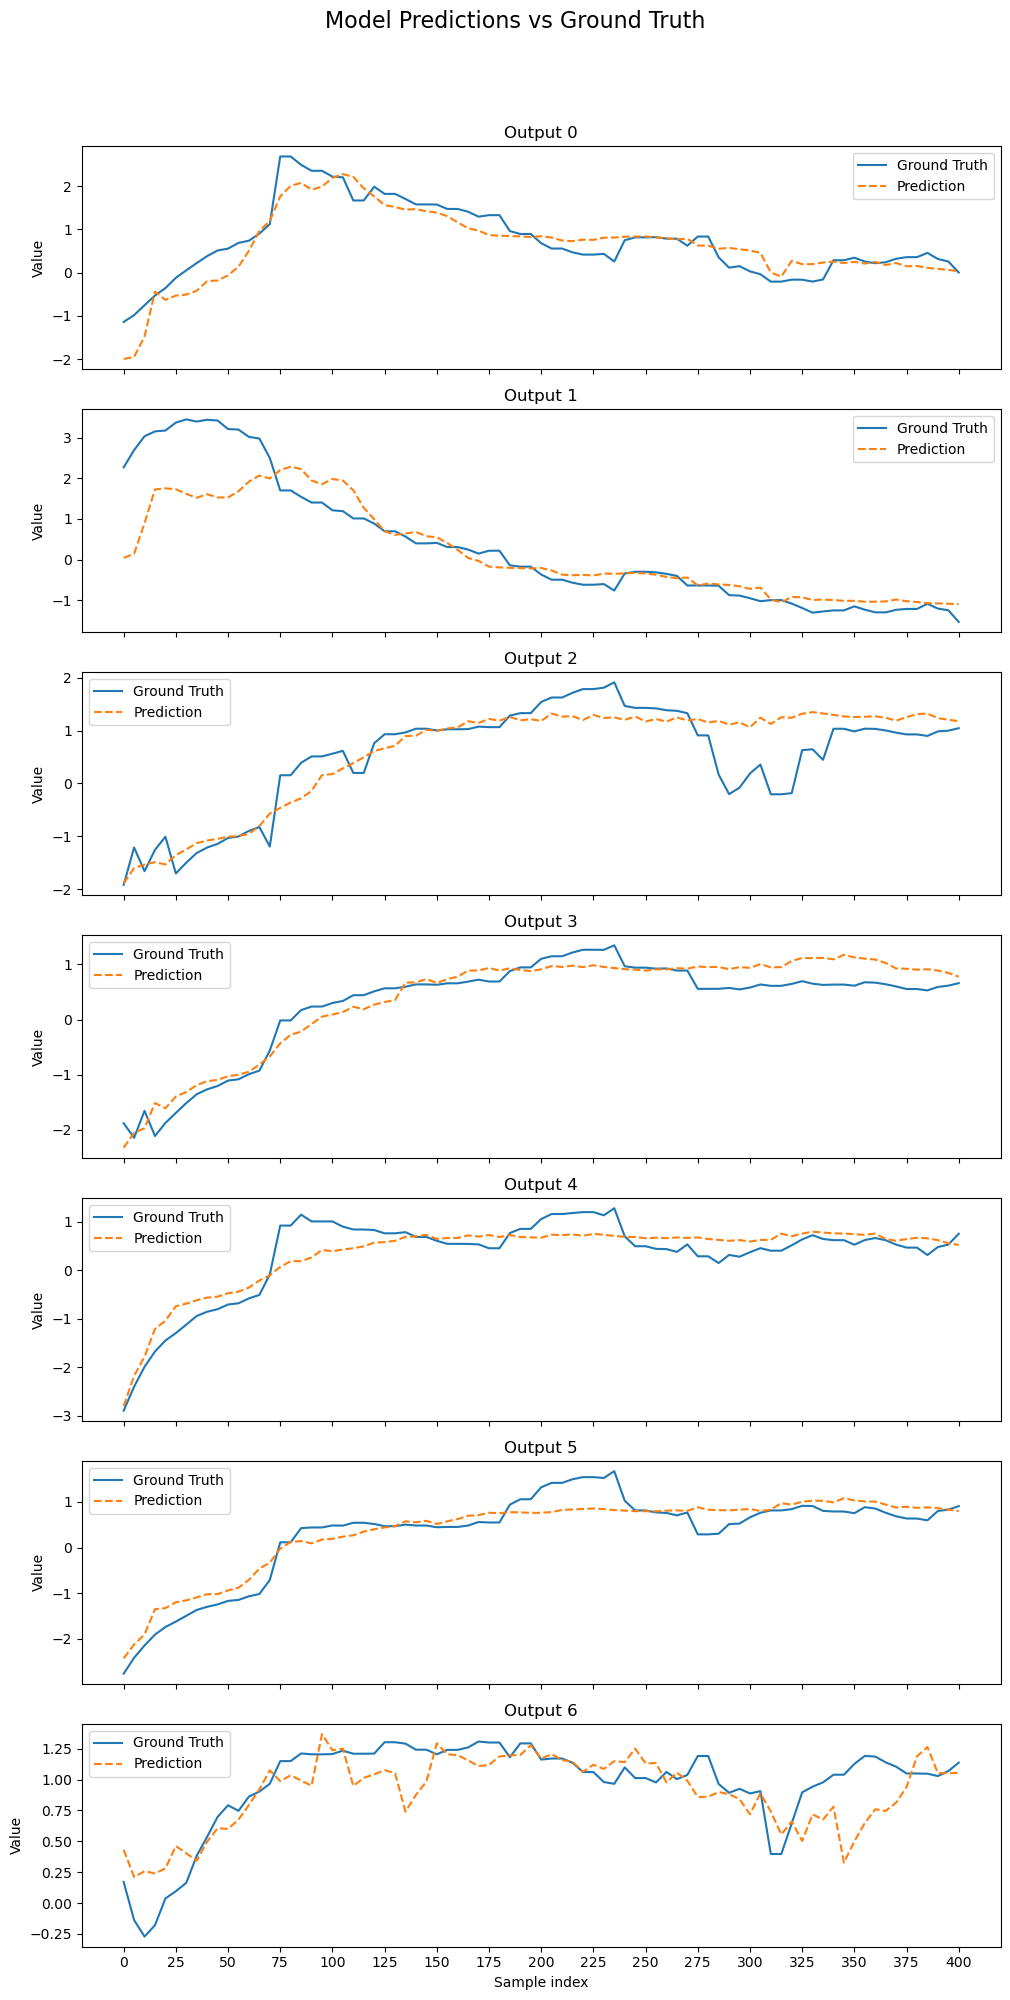

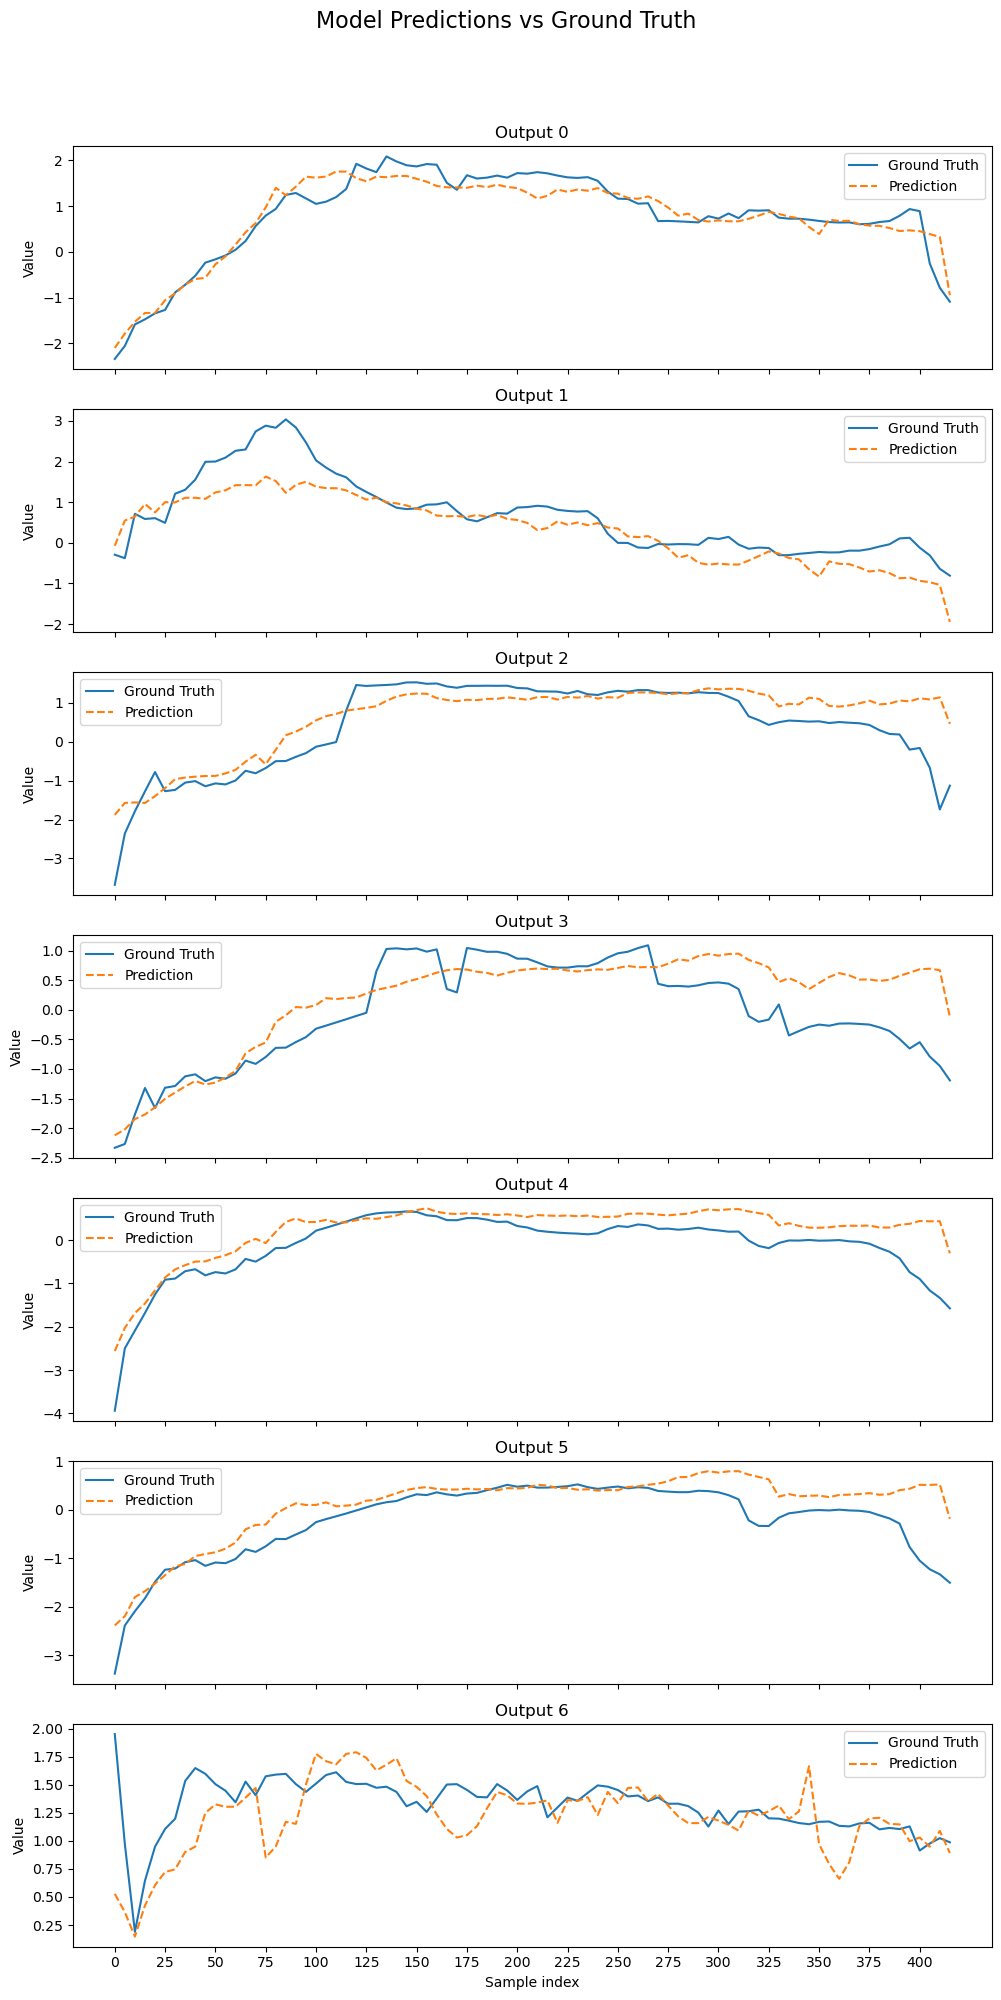

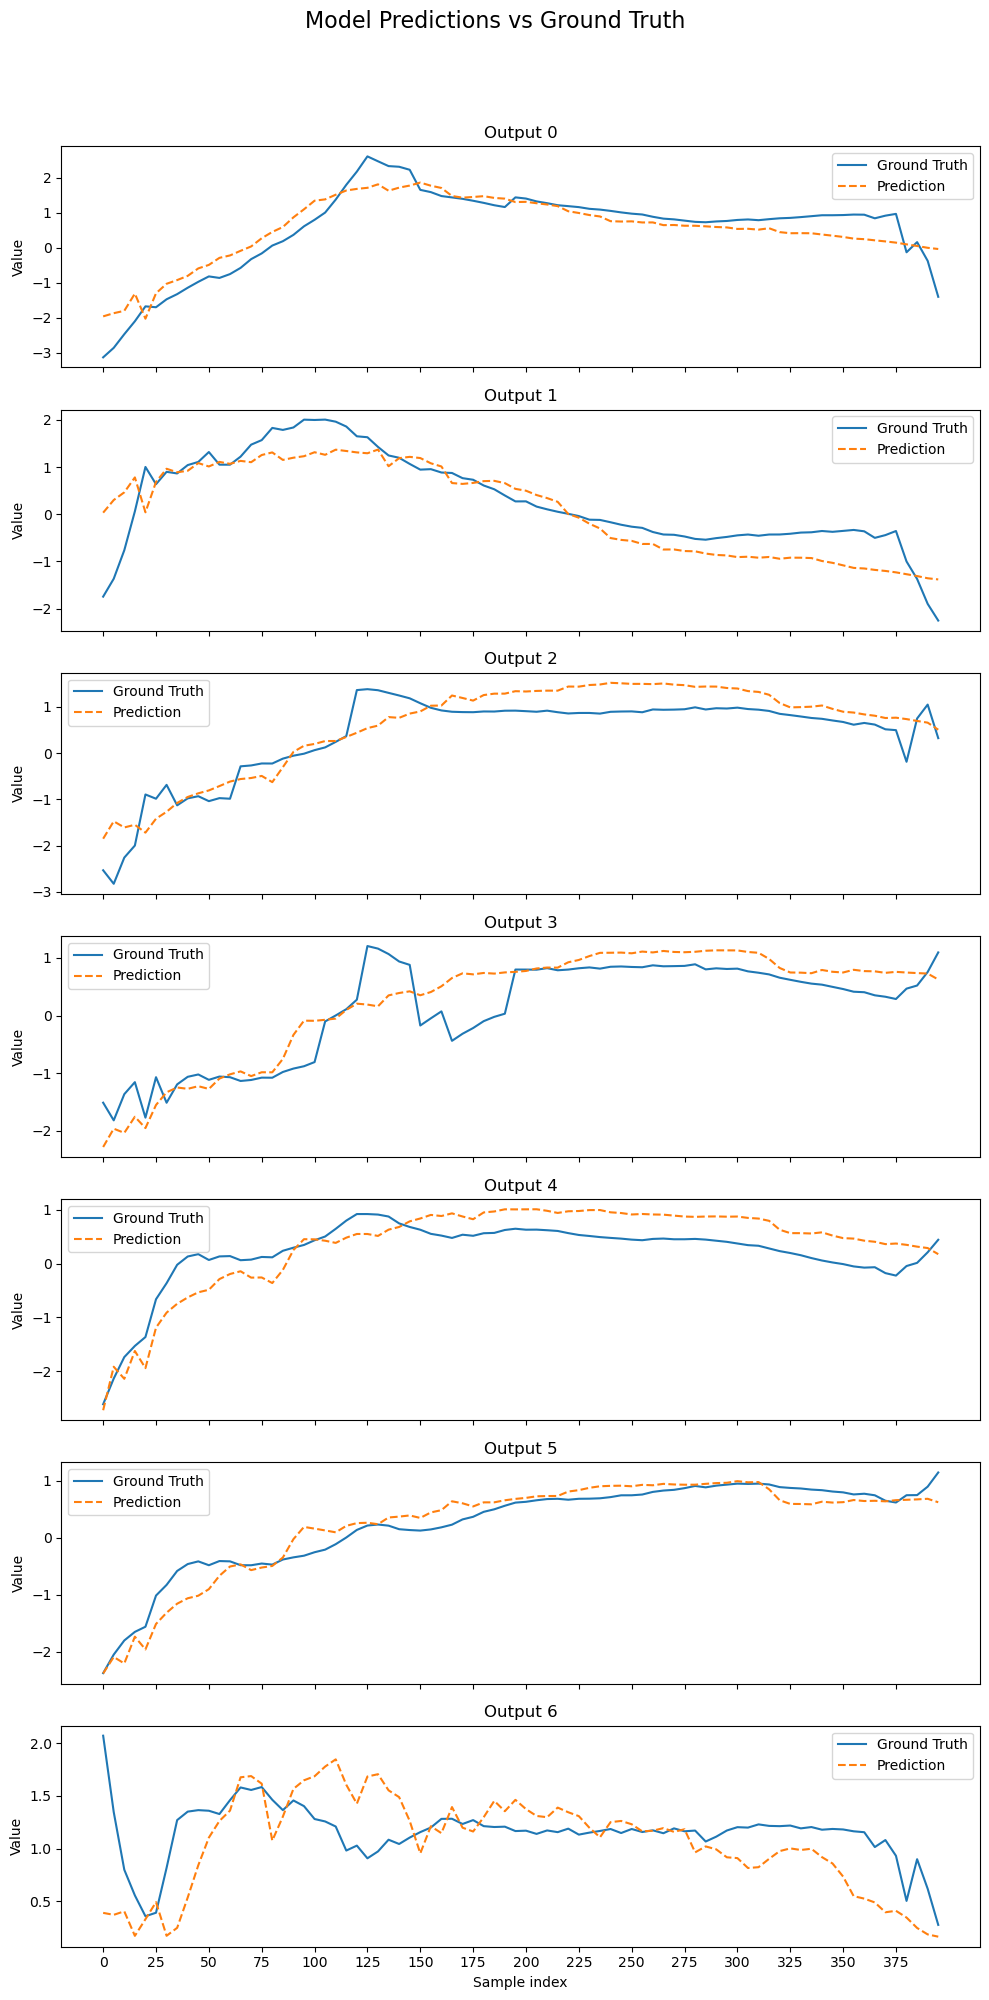

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# from torch.utils.data import DataLoader
# import torch

# from MAST_dataset import MAST_Dataset
# from scripts.pipeline_cecile.CNN_transform import CNN_Dataset

## Do Vizualization for just one shot !!!

# for shot_id in test_shots[0:3] :

    # print(shot_id)

cnn_shot_dataset = MastDataset(
                        local=True,
                        shots_list=test_shots[0:3],
                        source_signal_list=source_signal_list,
                        signal_level_transform_map=signal_transform_map,
                        shot_level_transform=shot_transform
                    )

print("len(mast_test_dataset)", len(cnn_shot_dataset))

shot_dataloader = DataLoader(
        cnn_shot_dataset,
        batch_size=1,
        num_workers=0,
        shuffle=False,
        collate_fn = flatten_then_collate
    )

print("dataloader ok")

cnn_model.eval()  # Set model to eval mode
criterion = torch.nn.MSELoss()
test_loss = 0.0
y_preds = []
y_trues = []

with torch.no_grad():
    for x_test, y_test in shot_dataloader:
        # Convert inputs to tensors with batch dim = 1
        # x_test = [torch.tensor(arr, dtype=torch.float32).to(device) for arr in x_test]
        # y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

        x_test = [arr.to(torch.float32).to(device) for arr in x_test]
        y_test = y_test[0].to(torch.float32).to(device)
        
        outputs = cnn_model(*x_test)
        loss = criterion(outputs, y_test)
        test_loss += loss.item()

        y_preds.append(outputs.cpu().squeeze(0).numpy())  # Remove batch dim before numpy
        y_trues.append(y_test.cpu().squeeze(0).numpy())

avg_test_loss = test_loss / len(y_test)
print(f"Test Loss: {avg_test_loss:.4f}")

#########   PLOT THE SHOT   ##########

for (y_preds_shot, y_trues_shot) in zip(y_preds, y_trues) :
    # Convert to NumPy arrays for further use or plotting
    y_preds_shot = np.stack(y_preds_shot)
    y_trues_shot = np.stack(y_trues_shot)

    num_outputs = y_preds_shot.shape[1]  # number of output dimensions
    num_samples = y_preds_shot.shape[0]  # number of samples

    fig, axes = plt.subplots(num_outputs, 1, figsize=(10, 3 * num_outputs), sharex=True)
    fig.suptitle("Model Predictions vs Ground Truth", fontsize=16)

    if num_outputs == 1:
        axes = [axes]

    for k in range(num_outputs):
        axes[k].plot(range(num_samples), y_trues_shot[:, k], label='Ground Truth')
        axes[k].plot(range(num_samples), y_preds_shot[:, k], label='Prediction', linestyle='--')
        axes[k].set_title(f'Output {k}')
        # axes[k].set_xticks([i for i in range(num_samples)], 
        #                    [ref_freq*i for i in range(num_samples)])
        step = 5  # show 1 out of every 5
        ticks = [i for i in range(0, num_samples, step)]
        labels = [int( REF_FREQ * i * 1000 ) for i in ticks]
        axes[k].set_xticks(ticks)
        axes[k].set_xticklabels(labels)
        axes[k].set_ylabel("Value")
        axes[k].legend()

    axes[-1].set_xlabel("Sample index")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()




